# _k_-Fold Cross Validation

In this tutorial, we will perform _k_-fold cross validation on the data that we prepared in **Tutorial 1, "Data Curation"**, using the
**[AMPL](https://github.com/ATOMScience-org/AMPL)** modules, classes and functions listed below.

- [parameter_parser](https://ampl.readthedocs.io/en/latest/pipeline.html#pipeline-parameter-parser-module)
- [ModelPipeline](https://ampl.readthedocs.io/en/latest/pipeline.html#pipeline.model_pipeline.ModelPipeline)
- [split_dataset](https://ampl.readthedocs.io/en/latest/pipeline.html#pipeline.model_pipeline.ModelPipeline.split_dataset)
- [compare_splits_plots](https://ampl.readthedocs.io/en/latest/utils.html#module-utils.compare_splits_plots)
- [split_response_dist_plots](https://ampl.readthedocs.io/en/latest/utils.html#module-utils.split_response_dist_plots)

In tutorial 02, we performed a a 3-way split of the curated dataset (train, validation, test). However, this method has limitations: it reduces the number of samples available for training, and the results can depend on which compounds happen 
to end up in each subset.

**_k_-fold Cross Validation** addresses this by splitting the data into _k_ equal subsets ("folds"). The model is trained on _k_ − 1 folds and validated on the remaining fold. This process is repeated _k_ times, with each fold serving as the validation set exactly once. Performance is then averaged across all _k_ iterations to give a more robust estimate of how well the model generalizes to new data.

During cross-validation, one model is trained for each fold. Each model is trained on a different subset of the data and evaluated on its corresponding validation fold. The reported training and validation metrics represent the average performance across all fold-specific models, providing a more robust estimate of expected model performance than a single train/validation split.

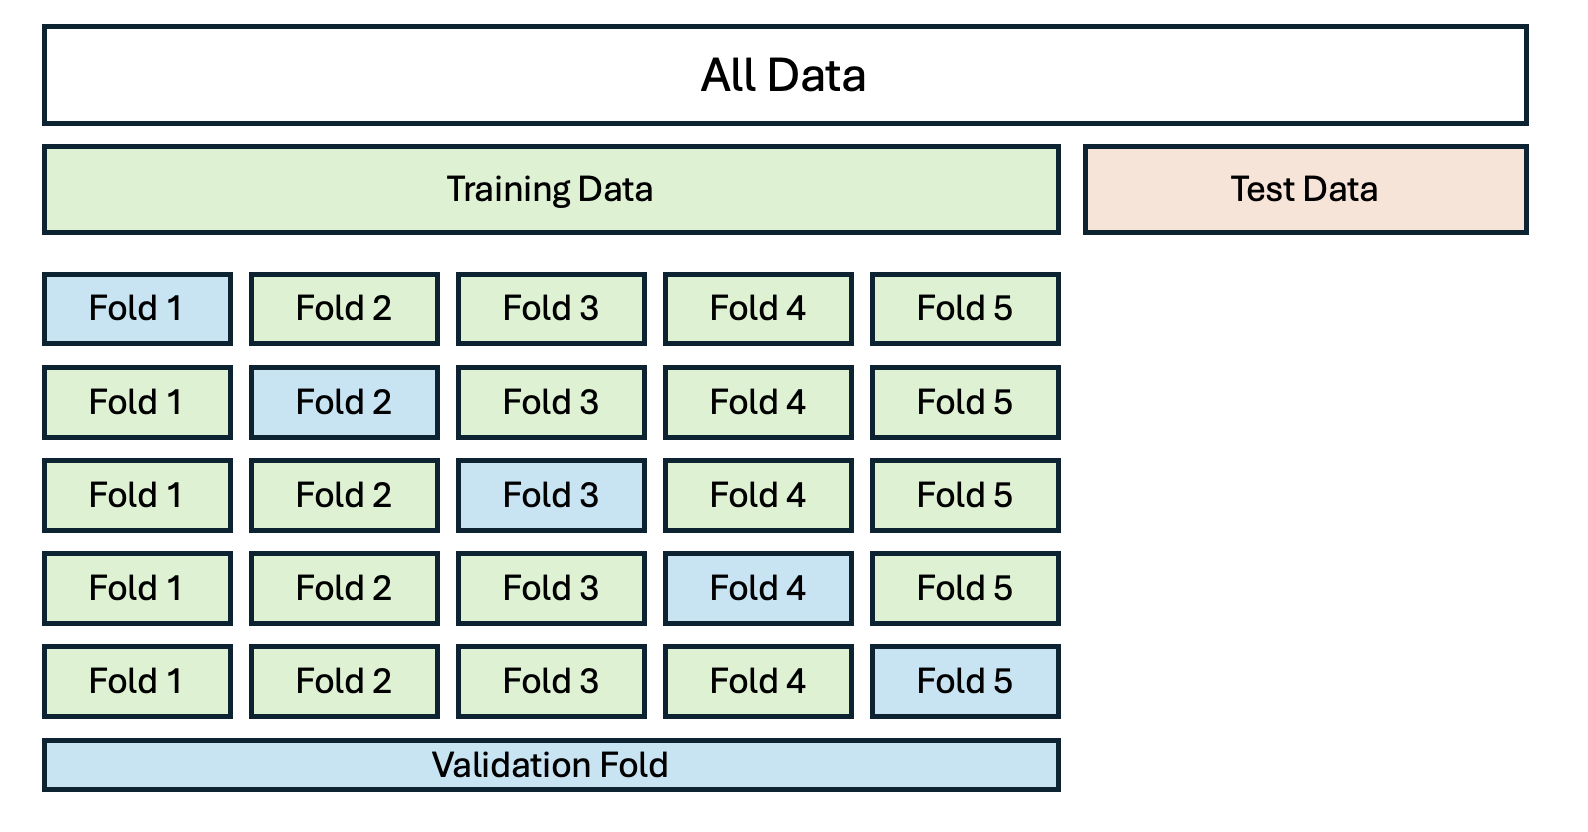

Importantly, there remains a true, holdout test set that the model will not see until after hyperparameter searching and model selection. The full workflow for training a model with cross validation is as follows:

1. Set aside a held-out test set that the model does not see during training or hyperparameter tuning
2. Run hyperparameter search using _k_-fold cross validation on the remaining data (~80%)
3. Evaluate each hyperparameter combination across all _k_ folds and select the best one
3. Retrain a single production model using the selected best hyperparameters on 100% of the training and validation data (all non-test data)
4. Evaluate final model performance on the held-out test set

The final model is used for predictions and deployment, compared to the cross-validation models which are only used to estimate model performance.

This approach can be more computationally expensive than the 3-way split, but makes better use of available data, which is an advantage when working with small datasets.

Note: During cross-validation, neural network models and tree-based models (Random Forest and XGBoost) follow slightly different internal training implementations. Neural networks determine the optimal training duration from the cross-validation results and then retrain the final production model for best epoch +1 epochs using the complete train/validation dataset. Random Forest and XGBoost models similarly retrain a single final model on the complete train/validation dataset after cross-validation, but do not require epoch selection.

Why +1? When you add more data (the held-out validation fold), the model can usually learn slightly longer before overfitting. The +1 is a heuristic approximation of this. Some people use a small multiplier instead (e.g., optimal_epochs * (k/(k-1))).

In [1]:
import pandas as pd

# Same set up
dataset_file = 'dataset/SLC6A3_Ki_curated.csv'
odir = 'dataset'

# Set for less chatty log messages
import logging
logger = logging.getLogger('ATOM')
logger.setLevel(logging.INFO)

## Performing a Split
We will split our data with a k-fold scaffold split. To do this, we only need to specify "k_fold_cv" as the `split_strategy`. For more information on scaffold splitting, refer to tutorial notebook 2.

In [2]:
params = {
    # dataset info
    "dataset_key" : dataset_file,
    "response_cols" : "avg_pKi",
    "id_col": "compound_id",
    "smiles_col" : "base_rdkit_smiles",
    "result_dir": odir,

    # splitting
    "previously_split": "False",
    "splitter": 'scaffold',
    "split_strategy": "k_fold_cv",
    "num_folds": "5", # default is 5
 
    # featurization & training params
    "featurizer": "computed_descriptors",
    "descriptor_type" : "rdkit_raw",
    "previously_featurized": "True",
}

In [ ]:
from atomsci.ddm.pipeline import model_pipeline as mp
from atomsci.ddm.pipeline import parameter_parser as parse

pparams = parse.wrapper(params)
MP = mp.ModelPipeline(pparams)
split_uuid = MP.split_dataset()

Again, the dataset split table is saved as a .csv in the same directory as the `dataset_key`. 

The name of the split file starts with the `dataset_key` and is followed by the `split_strategy` (k_fold_cv), `split type` (scaffold), and the `split_uuid` (a unique identifier of the split).

In [ ]:
# display the split file location
import glob
import os
dirname = os.path.dirname(params['dataset_key'])
split_file = glob.glob(f"{dirname}/*{split_uuid}*")[0]
split_file

'dataset/SLC6A3_Ki_curated_5_fold_cv_scaffold_e5ae743e-485d-42a6-a1cd-482a88b4d0df.csv'

### Format of the Split File
The split file consists of three columns: `cmpd_id` is the compound ID; `subset` tells you if the compound is in the train (train_valid) or test set and `fold` contains the fold index.

In [5]:
# Explore contents of the split file
split_df = pd.read_csv(split_file)
split_df.head()

,cmpd_id,subset,fold
0,CHEMBL577501,train_valid,0
1,CHEMBL204490,train_valid,0
2,CHEMBL566208,train_valid,0
3,CHEMBL1945248,train_valid,0
4,CHEMBL345689,train_valid,0


In [6]:
# Show the numbers of compounds in each split subset
split_df.subset.value_counts()

subset
train_valid    1637
test            182
Name: count, dtype: int64

### Visualizing Scaffold Splits
For _k_-fold cross validation, you would ideally visualize the **[Tanimoto distance](https://en.wikipedia.org/wiki/Jaccard_index#Tanimoto_similarity_and_distance)** distribution for each fold separately to confirm that scaffold splitting is creating structurally diverse splits across folds. We can manually loop over folds to visualize this. We can also visualize the distribution of input values in each fold. 

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import atomsci.ddm.utils.compare_splits_plots as csp

# read the dataset
df = pd.read_csv(dataset_file)

# read the split file
split = pd.read_csv(split_file)
split_type = params['splitter']

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/Users/echun/repos/AMPL/.venv-mchip/lib/python3.10/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'pkg_resources'
Skipped loading some Jax models, missing a dependency. No module named 'jax'


In [8]:
split[['subset','fold']].value_counts().sort_index()

subset       fold
test         0       182
train_valid  0       327
             1       327
             2       327
             3       328
             4       328
Name: count, dtype: int64

[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerator
[10:32:35] DEPRECATION WARNING: please use MorganGenerat

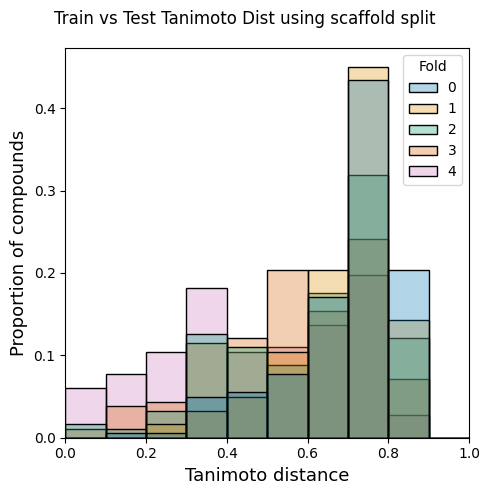

In [9]:
# plot Tanimoto distance histograms for all folds
fig, ax = plt.subplots(figsize=(5,5))

ss = csp.SplitStats(
    df, split,
    smiles_col='base_rdkit_smiles',
    id_col='compound_id',
    response_cols=['avg_pKi']
)
ax = ss.dist_hist_kfold_plot(n_bins=10) #n_bins=10 is default, can be changed to 20

fig.suptitle(f"Train vs Test Tanimoto Dist using {split_type} split")
plt.tight_layout()

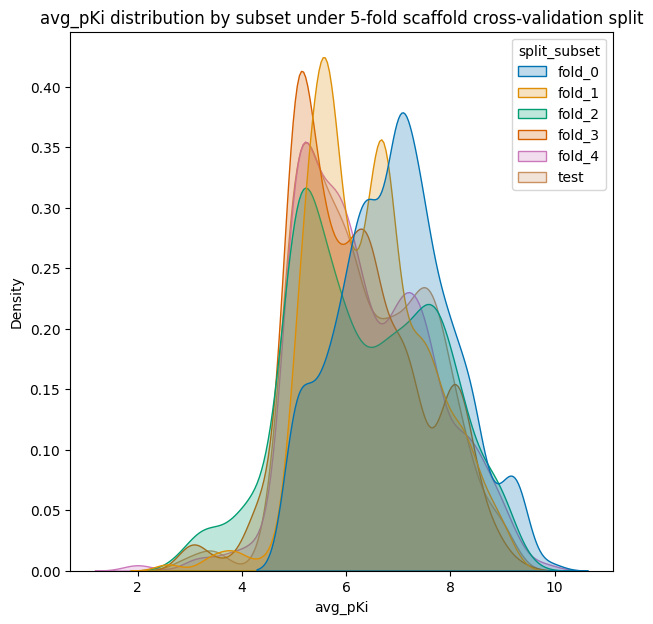

In [9]:
# visualize distributions of the response values (pKi) in each subset
import atomsci.ddm.utils.split_response_dist_plots as srdp
split_params = {
    "dataset_key" : dataset_file,
    "smiles_col" : "base_rdkit_smiles",
    "response_cols" : "avg_pKi",
    "split_uuid": split_uuid,
    "split_strategy": "k_fold_cv",
    "splitter": 'scaffold',
}
srdp.plot_split_subset_response_distrs(split_params)

## Training a Model
Now we can use our dataset and scaffold split to train a model with _k_-fold cross validation to predict the $pK_i$'s.

We will train a random forest model using the following inputs:

1. The curated **[SLC6A3](https://www.ebi.ac.uk/chembl/target_report_card/CHEMBL238)** dataset from **Tutorial 1, "Data Curation"**.
2. The split file generated in this notebook.
3. **[RDKit](https://github.com/rdkit/rdkit)** features calculated by the **[AMPL](https://github.com/ATOMScience-org/AMPL)** pipeline.

Here, we will use `"split_uuid": "e5ae743e-485d-42a6-a1cd-482a88b4d0df"` which is saved in `dataset/` as a convenience for these tutorials.

In [ ]:
# importing relevant libraries
pd.set_option('display.max_columns', None)
from atomsci.ddm.pipeline import model_pipeline as mp
from atomsci.ddm.pipeline import parameter_parser as parse

# Set up
dataset_file = 'dataset/SLC6A3_Ki_curated.csv'
odir='dataset/SLC6A3_models/'

response_col = "avg_pKi"
compound_id = "compound_id"
smiles_col = "base_rdkit_smiles"
split_uuid = "e5ae743e-485d-42a6-a1cd-482a88b4d0df"

params = {
        "prediction_type": "regression",
        "dataset_key": dataset_file,
        "id_col": compound_id,
        "smiles_col": smiles_col,
        "response_cols": response_col,

        "previously_split": "True",
        "split_strategy": "k_fold_cv",
        "splitter": 'scaffold',
        "split_uuid": split_uuid,
        "split_only": "False",

        "featurizer": "computed_descriptors",
        "descriptor_type" : "rdkit_raw",
        "model_type": "RF",
        "verbose": "True",
        "transformers": "True",
        "rerun": "False",
        "result_dir": odir
    }

ampl_param = parse.wrapper(params)
pl = mp.ModelPipeline(ampl_param)
pl.train_model()


### Performance of the Model
**[AMPL](https://github.com/ATOMScience-org/AMPL)** has several popular metrics to evaulate regression models; 
**Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)** and $R^2$ (R-Squared).
In our tutorials, we will use $R^2$ metric to compare our models. The best model will have the highest
$R^2$ score.

When using _k_-fold cross validation, we are actually training one model per each of the _k_ folds. The performance metrics returned are the average of the _k_ models. 

After model selection, AMPL retrains a single production model, whose performance is then evaluated separately on the held-out test set.

In [ ]:
# Model Performance
from atomsci.ddm.pipeline import compare_models as cm
perf_df = cm.get_filesystem_perf_results(odir, pred_type='regression') # printed statement will show all models in odir
perf_df = perf_df[perf_df.split_strategy == 'k_fold_cv']

In [ ]:
perf_df

In [ ]:
# save perf_df
perf_df.to_csv(os.path.join(odir, 'perf_df.csv'))

In [ ]:
perf_df = pd.read_csv('/Users/echun/repos/AMPL/atomsci/ddm/examples/tutorials/dataset/SLC6A3_models/perf_df.csv')

In [ ]:
# View the perf_df dataframe

# show most useful columns
perf_df[['model_uuid', 'split_uuid', 'best_train_r2_score', 'best_valid_r2_score', 'best_test_r2_score']]

### Finding the Top Performing Model

This may or may not be the _k_-fold cross validated regression model we just created. 
If you have models from the previous tutorials, those may have a better `best_valid_r2_score`.

In [ ]:
# Top performing model
top_model=perf_df.sort_values(by="best_valid_r2_score", ascending=False).iloc[0]
top_model

In [ ]:
# Top performing model path
top_model.model_path

## Application of the Trained Model
With _k_-fold cross validation, the final "production" model is trained on 100% of the train/validation data using the hyperparameters selected during cross-validation. This is different than the train_valid_test workflow, where the final model is only trained on the training data. 

As a best practice, the final production model should be evaluated on the held-out test set to verify that its performance is consistent with the cross-validation estimate. Small improvements are expected because the final model is trained on more data, but substantial deviations from the averaged cross-validation metrics should be looked into.

For more information on applying a trained model, please refer to tutorial notebook 4.

In [ ]:
import numpy as np

# ignore sklearn future warnings
import warnings
warnings.filterwarnings('ignore',category=FutureWarning)

from atomsci.ddm.pipeline import predict_from_model as pfm
from sklearn.metrics import r2_score

### Creating The Test Dataset
First, create a test set by selecting the test data from the curated dataset.
Here we are using the pre-featurized dataset to save time.

In [ ]:
split_file_path = 'dataset/SLC6A3_Ki_curated_5_fold_cv_scaffold_e5ae743e-485d-42a6-a1cd-482a88b4d0df.csv'
curated_data_path = 'dataset/scaled_descriptors/SLC6A3_Ki_curated_with_rdkit_raw_descriptors.csv'

split_data = pd.read_csv(split_file_path)

curated_data = pd.read_csv(curated_data_path)

test_ids=split_data[split_data.subset == 'test'].cmpd_id.unique()
test_data = curated_data[curated_data.compound_id.isin(test_ids)]

# show most useful columns 
test_data[['compound_id', 'base_rdkit_smiles', 'avg_pKi']].head()

### Performing Predictions

In [ ]:
model_dir = 'dataset/SLC6A3_models/SLC6A3_Ki_curated_model_02fec37e-67fa-407a-a59b-c7a7d1c4692c.tar.gz'
# model_dir = top_model.model_path
input_df = test_data
id_col = 'compound_id'
smiles_col = 'base_rdkit_smiles'
response_col = 'avg_pKi'

# loads a pretrained model from a model tarball file and runs predictions on 
# compounds in an input data frame
pred_df = pfm.predict_from_model_file(model_path = model_dir, 
                                      input_df = test_data,
                                      id_col = id_col ,
                                      smiles_col = smiles_col, 
                                      response_col = response_col,
                                      is_featurized=True)
                                      

# show most useful columns
pred_df[['compound_id', 'base_rdkit_smiles', 'avg_pKi_actual','avg_pKi_pred', 'avg_pKi_std']].head()

### Evaluating Prediction Performance
Calculate the $R^2$ score and compare it with the expected test $R^2$
score.

In [ ]:
actual_value = pred_df["avg_pKi_actual"]
predicted_value = pred_df["avg_pKi_pred"]
r2 = np.round(r2_score(actual_value, predicted_value), 6)

expected_r2 = top_model.best_test_r2_score

print(f"Expected test R²: {expected_r2:.6f}")
print(f"Calculated test R²: {r2:.6f}")

### Visualizing Prediction Results

In [ ]:
from atomsci.ddm.pipeline import perf_plots as pp

In [ ]:
# Plots predicted vs actual values from a trained regression model for a given 
# dataframe
pp.plot_pred_vs_actual_from_df(pred_df, 
                               actual_col='avg_pKi_actual', 
                               pred_col='avg_pKi_pred', 
                               label='Prediction of Test Set');

If you have specific feedback about a tutorial, please complete the **[AMPL Tutorial Evaluation](https://forms.gle/pa9sHj4MHbS5zG7A6)**.